# Credit Card Fraud Detection Using XGBoost

## Problem Statement

Credit card fraud detection is a binary classification problem in which
transactions are classified as legitimate or fraudulent.

The major challenge is severe class imbalance because fraudulent transactions
represent only a small proportion of all transactions.

In this case study, we use the BankSim financial transaction dataset and apply
SMOTE to handle class imbalance, XGBoost for fraud classification, decision
threshold tuning to control the precision-recall trade-off, and feature
importance analysis to interpret the model.

In [1]:
# Import pandas for data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

# Model evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

# XGBoost classifier
from xgboost import XGBClassifier

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the main BankSim transaction dataset
df = pd.read_csv("/content/credit_card_fraud.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 38726
Number of columns: 10


In [5]:
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0.0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0.0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0.0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0.0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0.0


In [6]:
# Display all column names
print(df.columns.tolist())

['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38726 entries, 0 to 38725
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   step         38726 non-null  int64  
 1   customer     38726 non-null  object 
 2   age          38726 non-null  object 
 3   gender       38726 non-null  object 
 4   zipcodeOri   38726 non-null  object 
 5   merchant     38726 non-null  object 
 6   zipMerchant  38726 non-null  object 
 7   category     38726 non-null  object 
 8   amount       38725 non-null  float64
 9   fraud        38725 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 3.0+ MB


In [8]:
# Check the number of missing values in each column
print(df.isnull().sum())

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         1
fraud          1
dtype: int64


In [9]:
# Check for duplicate transactions
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
# Check the unique values of the target variable
print(df["fraud"].unique())

[ 0.  1. nan]


In [11]:
# Remove rows containing missing values
df = df.dropna()

# Reset the index after removing the rows
df = df.reset_index(drop=True)

# Check missing values again
print(df.isnull().sum())

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64


In [12]:
# Check the unique values of the fraud target
print(df["fraud"].unique())

[0. 1.]


In [13]:
# Count legitimate and fraudulent transactions
print(df["fraud"].value_counts())

fraud
0.0    38125
1.0      600
Name: count, dtype: int64


In [14]:
# Calculate fraud percentage
fraud_percentage = df["fraud"].mean() * 100

print("Fraud percentage:", round(fraud_percentage, 2), "%")

Fraud percentage: 1.55 %


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of
fraudulent and legitimate transactions and identify patterns in transaction
amount, category, age, and gender.

### 1.) Fraud vs Non-Fraud Transactions

The class distribution is visualized to understand the imbalance between
legitimate and fraudulent transactions.

Legitimate transactions: 38125
Fraudulent transactions: 600


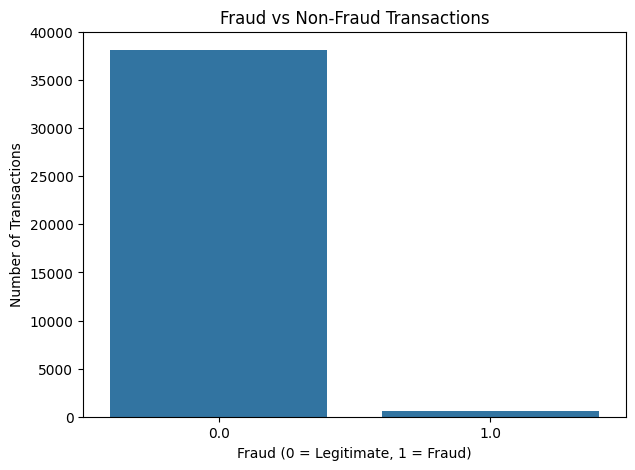

In [15]:
# Count legitimate and fraudulent transactions
fraud_counts = df["fraud"].value_counts()

print("Legitimate transactions:", fraud_counts[0.0])
print("Fraudulent transactions:", fraud_counts[1.0])

# Plot the class distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="fraud")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

### 2.) Transaction Amount Distribution

Transaction amounts are analyzed to identify differences between legitimate
and fraudulent transactions.

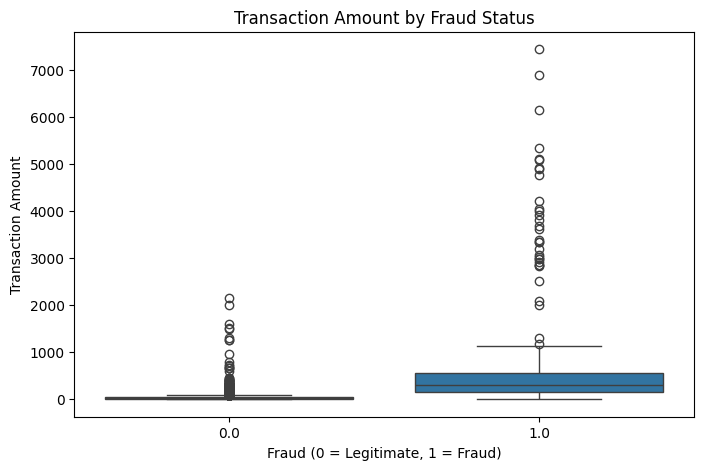

In [16]:
# Compare transaction amounts for legitimate and fraudulent transactions
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fraud",
    y="amount"
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

### 3.) Fraudulent Transactions by Category

The distribution of fraudulent transactions across different transaction
categories is analyzed to identify categories associated with fraud cases.

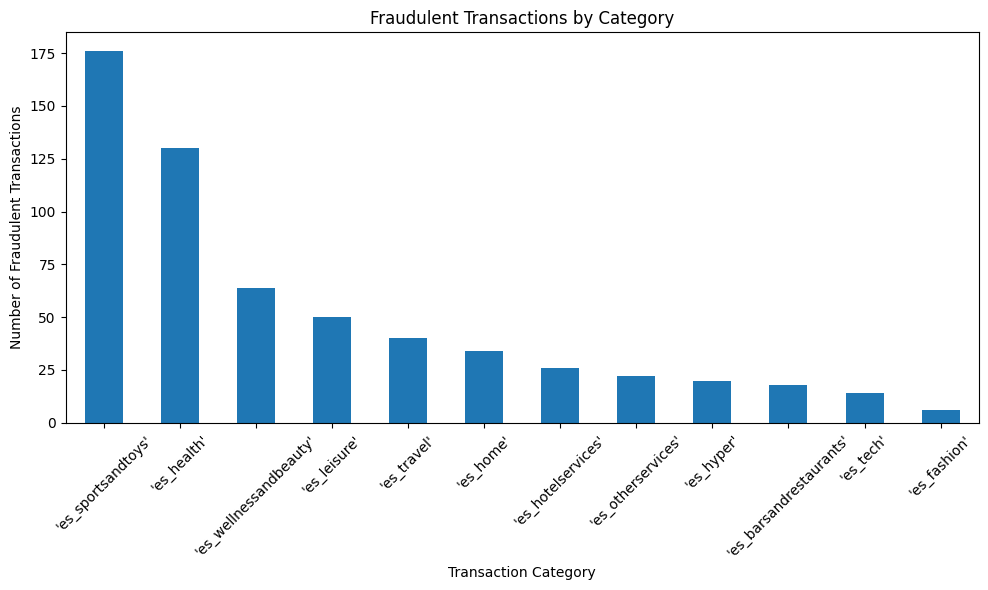

In [17]:
# Select only fraudulent transactions
fraud_transactions = df[df["fraud"] == 1]

# Count fraud cases for each transaction category
fraud_by_category = fraud_transactions["category"].value_counts()

# Plot the results
plt.figure(figsize=(10, 6))

fraud_by_category.plot(kind="bar")

plt.title("Fraudulent Transactions by Category")
plt.xlabel("Transaction Category")
plt.ylabel("Number of Fraudulent Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 4.) Fraudulent Transactions by Age Group

The distribution of fraudulent transactions across customer age groups is
analyzed to identify possible differences in fraud patterns.

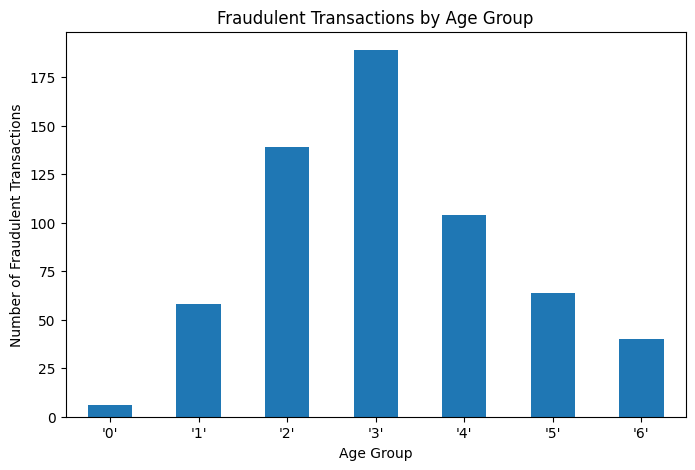

In [18]:
# Count fraudulent transactions by age group
fraud_by_age = df[df["fraud"] == 1]["age"].value_counts().sort_index()

# Plot the results
plt.figure(figsize=(8, 5))

fraud_by_age.plot(kind="bar")

plt.title("Fraudulent Transactions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Fraudulent Transactions")

plt.xticks(rotation=0)

plt.show()

### 5.) Fraudulent Transactions by Gender

The number of fraudulent transactions is compared across customer gender
categories.

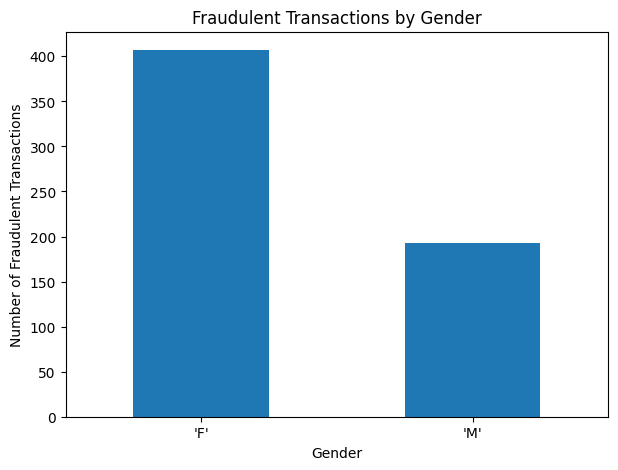

In [19]:
# Count fraudulent transactions by gender
fraud_by_gender = df[df["fraud"] == 1]["gender"].value_counts()

# Plot the results
plt.figure(figsize=(7, 5))

fraud_by_gender.plot(kind="bar")

plt.title("Fraudulent Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Fraudulent Transactions")

plt.xticks(rotation=0)

plt.show()

### 6.) Fraud Rate by Transaction Category

Instead of only counting fraudulent transactions, we calculate the percentage
of transactions within each category that are fraudulent.

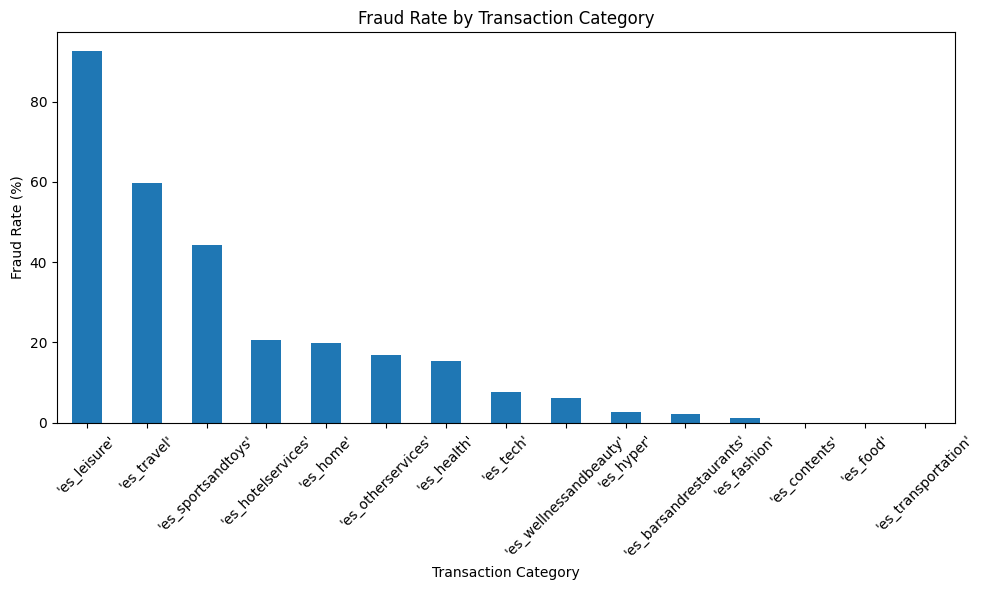

In [21]:
# Plot fraud rate by category
plt.figure(figsize=(10, 6))

fraud_rate_category.plot(kind="bar")

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Transaction Category")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Feature Selection

We select the relevant transaction attributes for fraud detection.

- `step` and `amount` are numerical features.
- `age`, `gender`, `merchant`, and `category` are categorical features.
- `customer`, `zipcodeOri`, and `zipMerchant` are treated as identifiers and are removed.
- `fraud` is the target variable.

In [22]:
# Select useful features for the model

features = [
    "step",
    "age",
    "gender",
    "merchant",
    "category",
    "amount"
]

X = df[features]
y = df["fraud"]

print("Features selected:")
print(X.columns.tolist())

print("\nTarget variable: fraud")

Features selected:
['step', 'age', 'gender', 'merchant', 'category', 'amount']

Target variable: fraud


## Encode Categorical Features

Categorical variables are converted into numerical form using One-Hot Encoding.

One-Hot Encoding creates separate binary columns for each category, allowing
the machine learning model to process categorical information.

In [23]:
# Convert categorical columns into numerical columns

X = pd.get_dummies(
    X,
    columns=["age", "gender", "merchant", "category"],
    drop_first=True
)

print("Shape after encoding:", X.shape)

X.head()

Shape after encoding: (38725, 74)


,step,amount,age_'1',age_'2',age_'3',age_'4',age_'5',age_'6',age_'U',gender_'F',...,category_'es_home',category_'es_hotelservices',category_'es_hyper',category_'es_leisure',category_'es_otherservices',category_'es_sportsandtoys',category_'es_tech',category_'es_transportation',category_'es_travel',category_'es_wellnessandbeauty'
0,0,4.55,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0,39.68,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0,26.89,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,0,17.25,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0,35.72,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is reserved for testing.
- Stratification is used to maintain the fraud-to-legitimate transaction ratio
  in both sets.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (30980, 74)
Testing data: (7745, 74)

Training class distribution:
fraud
0.0    30500
1.0      480
Name: count, dtype: int64

Testing class distribution:
fraud
0.0    7625
1.0     120
Name: count, dtype: int64


## Class Imbalance

Fraudulent transactions represent a much smaller proportion of the dataset
than legitimate transactions.

This class imbalance can cause a model to favor the majority class.
Therefore, SMOTE is applied to the training data to create synthetic samples
of the minority fraud class.

Before SMOTE:
fraud
0.0    30500
1.0      480
Name: count, dtype: int64


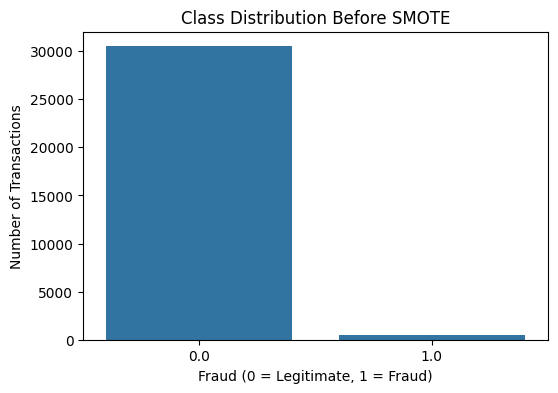

In [25]:
# Check class distribution before SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

## Apply SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is applied only to the
training data.

It generates synthetic examples of fraudulent transactions so that the
model receives a more balanced training dataset.

The original test data remains unchanged for unbiased evaluation.

In [26]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
fraud
0.0    30500
1.0      480
Name: count, dtype: int64

After SMOTE:
fraud
0.0    30500
1.0    30500
Name: count, dtype: int64


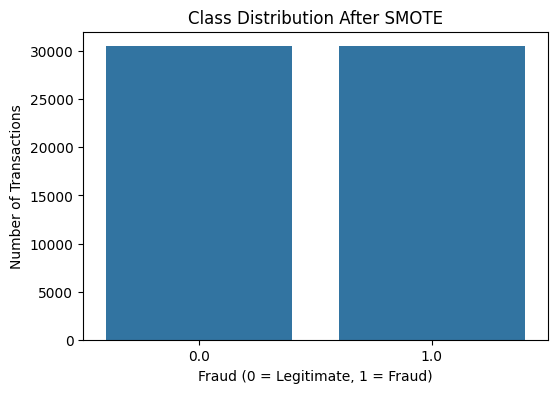

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

## Train XGBoost Model

XGBoost (Extreme Gradient Boosting) is used to classify transactions as
legitimate or fraudulent.

The model is trained on the SMOTE-balanced training dataset.

In [28]:
from xgboost import XGBClassifier

# Create the XGBoost classifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
model.fit(X_train_smote, y_train_smote)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


## Make Predictions

The trained XGBoost model is used to predict fraud on the test dataset.

Both class predictions and fraud probabilities are obtained.

In [29]:
# Predict class labels
y_pred = model.predict(X_test)

# Predict probability of fraud
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


## Model Evaluation

The model is evaluated using:

- Confusion Matrix
- Precision
- Recall
- F1-Score
- ROC-AUC

Recall is particularly important because it measures how many actual
fraudulent transactions are correctly detected.

In [31]:
# Calculate ROC-AUC score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.9891


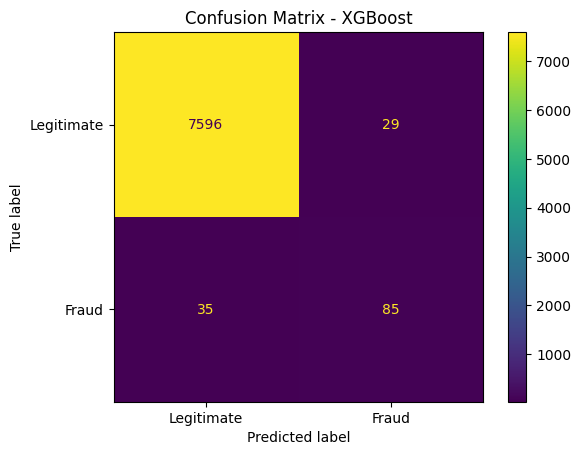

In [32]:
# Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

## Decision Threshold Tuning

By default, a transaction is classified as fraudulent when its predicted
fraud probability is at least 0.50.

Different thresholds are tested to study the trade-off between precision
and recall.

The F1-score is used as the comparison metric because it balances
precision and recall.

In [33]:
# Test different probability thresholds

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for threshold in thresholds:

    # Convert probabilities into class predictions
    y_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_threshold, zero_division=0)
    recall = recall_score(y_test, y_threshold, zero_division=0)
    f1 = f1_score(y_test, y_threshold, zero_division=0)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1-Score"]
)

threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.1,0.494681,0.775000,0.603896
1,0.2,0.566038,0.750000,0.645161
2,0.3,0.633803,0.750000,0.687023
3,0.4,0.700787,0.741667,0.720648
4,0.5,0.745614,0.708333,0.726496


In [34]:
# Find the threshold with the highest F1-score

best_row = threshold_results.loc[
    threshold_results["F1-Score"].idxmax()
]

print("Threshold with highest F1-score:")
print(best_row)

Threshold with highest F1-score:
Threshold    0.500000
Precision    0.745614
Recall       0.708333
F1-Score     0.726496
Name: 4, dtype: float64


## Feature Importance

Feature importance is used to identify which transaction attributes contribute
most to the XGBoost model's fraud predictions.

This helps interpret the factors that the model considers important for
fraud detection.

In [35]:
# Get feature importance from the trained model

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

# Select top 10 important features
top_features = importance.sort_values(
    ascending=False
).head(10)

print("Top 10 Important Features:")
print(top_features)

Top 10 Important Features:
category_'es_transportation'       0.824494
category_'es_sportsandtoys'        0.033031
merchant_'M85975013'               0.013199
merchant_'M1294758098'             0.012463
merchant_'M980657600'              0.009626
merchant_'M480139044'              0.008819
gender_'M'                         0.007009
category_'es_hotelservices'        0.005349
amount                             0.005074
category_'es_wellnessandbeauty'    0.004562
dtype: float32


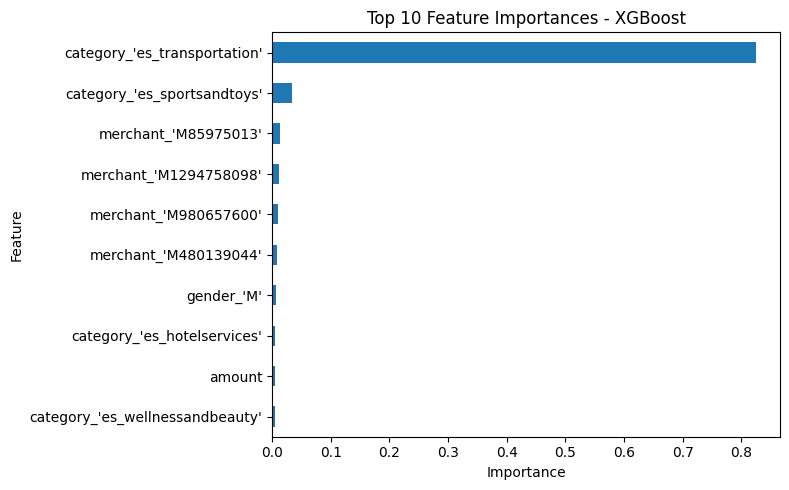

In [36]:
plt.figure(figsize=(8, 5))

top_features.sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Final Model Evaluation

The decision threshold selected during threshold tuning is applied to the
test-set fraud probabilities.

The final precision, recall, and F1-score are calculated using this threshold.

In [37]:
# Apply the selected threshold
best_threshold = best_row["Threshold"]

final_predictions = (y_prob >= best_threshold).astype(int)

# Calculate final metrics
final_precision = precision_score(
    y_test, final_predictions, zero_division=0
)

final_recall = recall_score(
    y_test, final_predictions, zero_division=0
)

final_f1 = f1_score(
    y_test, final_predictions, zero_division=0
)

print("Selected Threshold:", best_threshold)
print("Final Precision:", round(final_precision, 4))
print("Final Recall:", round(final_recall, 4))
print("Final F1-Score:", round(final_f1, 4))

Selected Threshold: 0.5
Final Precision: 0.7456
Final Recall: 0.7083
Final F1-Score: 0.7265


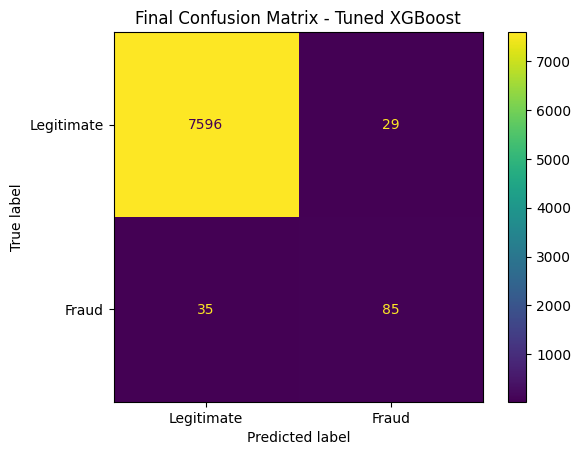

In [38]:
# Final confusion matrix using the selected threshold

cm_final = confusion_matrix(y_test, final_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Final Confusion Matrix - Tuned XGBoost")
plt.show()

## Conclusion

The BankSim dataset was used to develop a fraud detection model using
XGBoost.

The complete machine learning workflow included:

- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Feature Selection
- One-Hot Encoding
- Train-Test Split
- SMOTE for Class Imbalance
- XGBoost Classification
- Model Evaluation
- Decision Threshold Tuning
- Feature Importance Analysis

SMOTE helped address the imbalance between legitimate and fraudulent
transactions. XGBoost was then trained on the balanced training data.

Decision threshold tuning was performed to study the trade-off between
precision and recall. Feature importance analysis showed which transaction
attributes were most useful to the model when distinguishing between
legitimate and fraudulent transactions.